**EDA & Outliers**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import files
uploaded = files.upload()

height_weight = list(uploaded.keys())[0]

df = pd.read_csv(height_weight)

print("Dataset loaded successfully!")
print(df.head())
print(df.columns)
print(df.info())

Saving height_weight.csv to height_weight (4).csv
Dataset loaded successfully!
   Height  Weight
0   68.39  157.99
1   65.97  143.60
2   68.96  143.98
3   72.29  147.47
4   65.61  139.58
Index(['Height', 'Weight'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  1000 non-null   float64
 1   Weight  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB
None


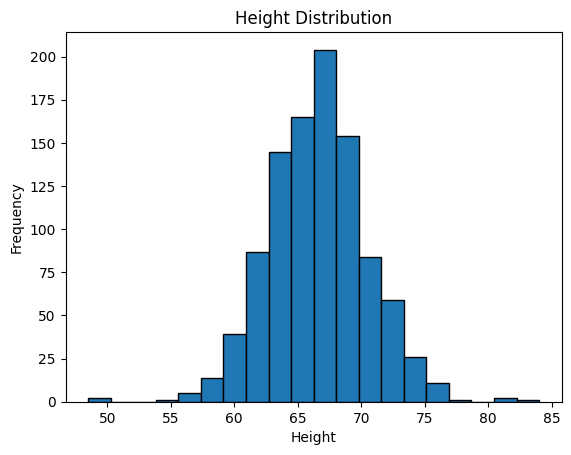

In [6]:
# Plot Histogram for Height
plt.hist(df["Height"], bins=20, edgecolor="black")

plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()


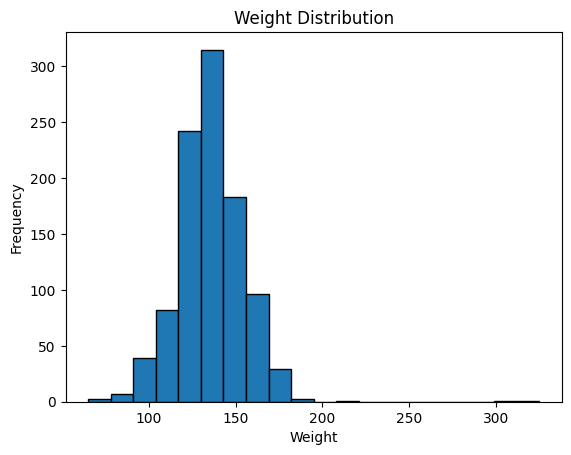

In [7]:
# Plot Histogram for Weight
plt.hist(df["Weight"], bins=20, edgecolor="black")

plt.title("Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")

plt.show()

In [9]:
# Detect Weight Outliers Using IQR
Q1 = df["Weight"].quantile(0.25)
Q3 = df["Weight"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

weight_outliers = df[
    (df["Weight"] < lower_limit) |
    (df["Weight"] > upper_limit)
]

print("Weight Outliers:")
print(weight_outliers)

Q1: 124.8175
Q3: 146.1925
IQR: 21.375
Lower Limit: 92.755
Upper Limit: 178.255
Weight Outliers:
     Height  Weight
37    59.05   90.02
60    64.68   75.00
160   62.80   91.07
209   81.14  208.10
285   59.08   91.72
340   63.38  310.00
346   61.00   83.94
355   62.69   89.59
374   74.68  181.51
387   73.63  178.80
491   72.12  185.34
531   60.19   90.45
539   64.31   92.04
568   59.39   90.06
624   72.55  178.67
680   69.24   65.00
707   73.17  181.20
750   62.99   89.33
755   76.50  186.89
880   76.10  180.55
910   65.33  325.00
957   68.24  178.30
971   63.91   89.80


In [10]:
# Detect Height Outliers Using IQR
Q1 = df["Height"].quantile(0.25)
Q3 = df["Height"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

height_outliers = df[
    (df["Height"] < lower_limit) |
    (df["Height"] > upper_limit)
]

print("Height Outliers:")
print(height_outliers)

Q1: 64.0275
Q3: 68.9725
IQR: 4.944999999999993
Lower Limit: 56.610000000000014
Upper Limit: 76.38999999999999
Height Outliers:
     Height  Weight
25    50.00  141.15
74    56.54  110.52
179   76.84  158.37
209   81.14  208.10
210   82.00  127.28
262   54.18   96.52
478   78.20  165.87
646   56.25   95.26
668   56.43  108.22
755   76.50  186.89
775   48.50   97.08
930   84.00  112.05


In [13]:
# Replace Weight Outliers With Mean
Q1 = df["Weight"].quantile(0.25)
Q3 = df["Weight"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

weight_mean = df["Weight"].mean()

df.loc[
    (df["Weight"] < lower_limit) |
    (df["Weight"] > upper_limit),
    "Weight"
] = weight_mean


In [14]:
# Replace Height Outliers With Median
Q1 = df["Height"].quantile(0.25)
Q3 = df["Height"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

height_median = df["Height"].median()

df.loc[
    (df["Height"] < lower_limit) |
    (df["Height"] > upper_limit),
    "Height"
] = height_median

In [15]:
# Print Dataset After Replacing Outliers
print("Dataset After Replacing Outliers:")
print(df)

df.head(10)

Dataset After Replacing Outliers:
     Height  Weight
0     68.39  157.99
1     65.97  143.60
2     68.96  143.98
3     72.29  147.47
4     65.61  139.58
..      ...     ...
995   65.43  143.40
996   73.33  158.67
997   68.94  132.58
998   64.33  124.63
999   68.68  133.29

[1000 rows x 2 columns]


,Height,Weight
0,68.39,157.99
1,65.97,143.60
2,68.96,143.98
3,72.29,147.47
4,65.61,139.58
5,65.61,135.92
6,72.50,166.75
7,69.42,152.52
8,64.72,140.57
9,68.56,135.40


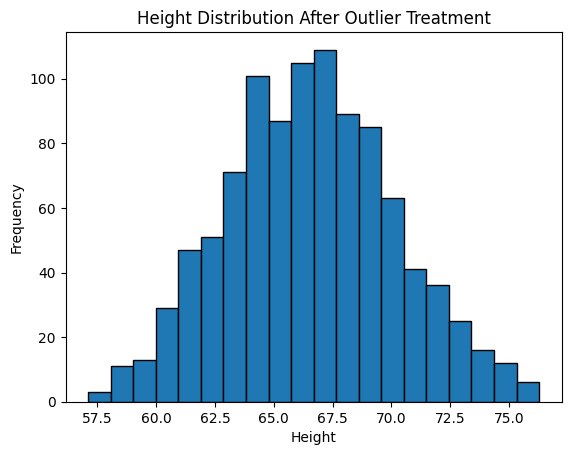

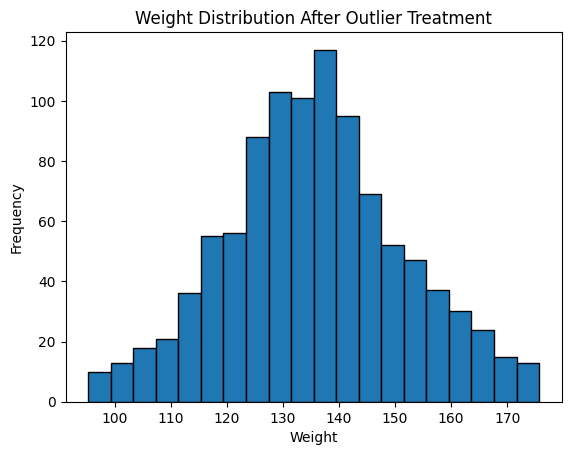

In [17]:
# Final Histograms After Outlier Treatment
plt.hist(df["Height"], bins=20, edgecolor="black")

plt.title("Height Distribution After Outlier Treatment")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()

plt.hist(df["Weight"], bins=20, edgecolor="black")

plt.title("Weight Distribution After Outlier Treatment")
plt.xlabel("Weight")
plt.ylabel("Frequency")

plt.show()